**import block**

In [1]:
import mne 
import scipy 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib widget

#can run this in order to stop the verbose outputs from MNE
#mne.set_log_level('WARNING')


Creating RawArray with float64 data, n_channels=4, n_times=46081
    Range : 0 ... 46080 =      0.000 ...   180.000 secs
Ready.
Creating RawArray with float64 data, n_channels=4, n_times=26881
    Range : 0 ... 26880 =      0.000 ...   105.000 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (6.605 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal ban

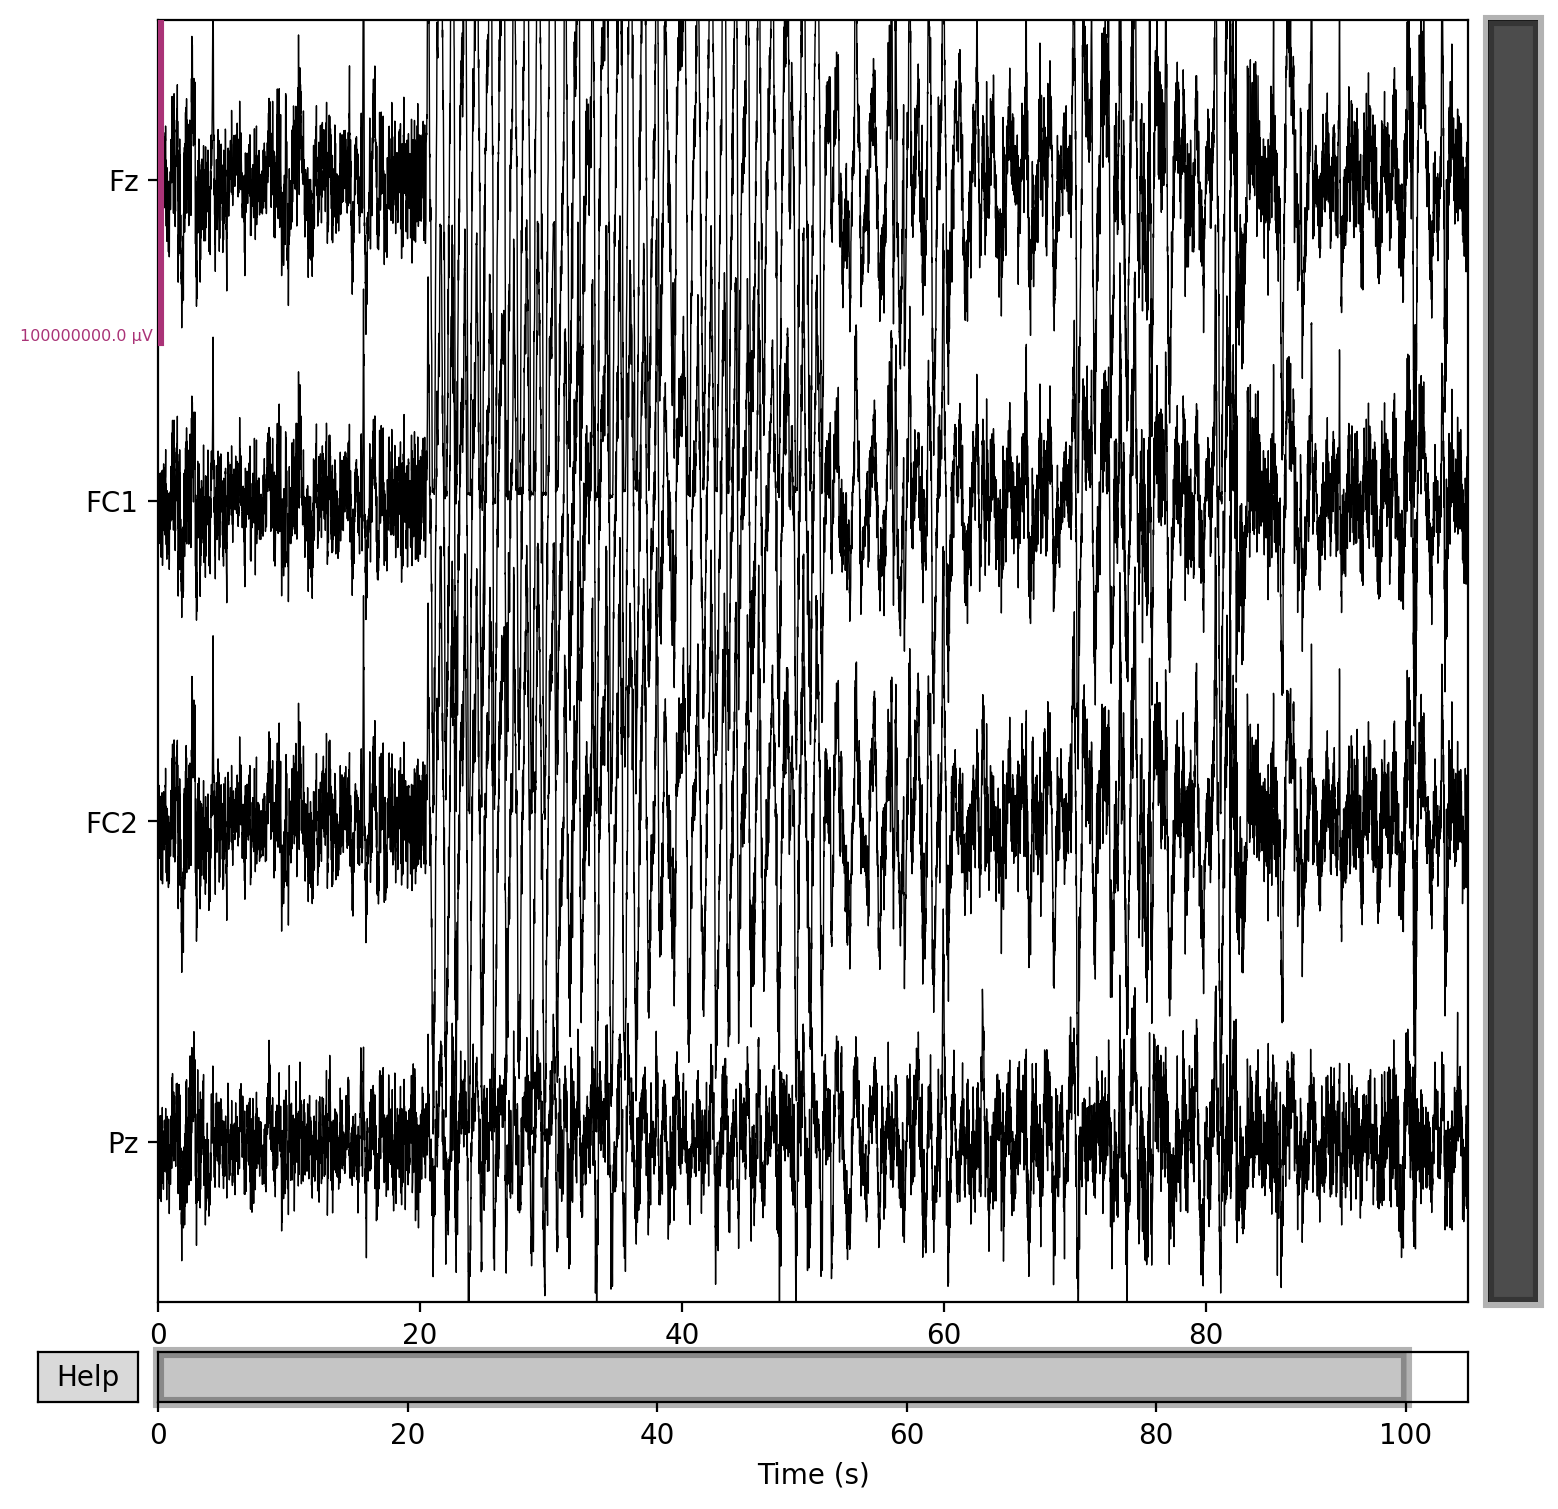

In [19]:
import h5py
import numpy as np
import mne

DATA_PATH = '/Users/alexanderspeer/Desktop/eeg-data/lab2-artifact-detection/eeg-data/Exp1_Monopolar_Fz-FC1-FC2-Pz_6x30s_fs256.mat'

# 1. LOAD
with h5py.File(DATA_PATH, 'r') as file:
    eeg = file['y'][:]

if eeg.shape[0] > eeg.shape[1]:
    eeg = eeg.T

#time and sampling rate

time = eeg[0]
fs = (1 / ((np.mean(np.diff(time)))))
#print(fs)

#creating an info object in MNE
channel_names = ['Fz', 'FC1', 'FC2', 'Pz']

info = mne.create_info(
    ch_names = channel_names,
    sfreq = fs,
    ch_types = 'eeg',
    verbose=None
)

#create a raw object now
raw = mne.io.RawArray(eeg[1:], info, verbose=None)

# crop FIRST to remove the giant artifacts
raw.crop(tmin=10, tmax=115, verbose=None)

# now winsor on clean data
data = raw.get_data()
lower = np.percentile(data, 1)
upper = np.percentile(data, 99)
data = np.clip(data, lower, upper)

# put it back
raw = mne.io.RawArray(data, raw.info) #don't have to do raw.info, just info is fine. 

#add a bandpass and notch
raw.filter(0.5, 40, verbose=None)
raw.notch_filter(60, verbose=None)

%matplotlib qt
import matplotlib
matplotlib.use('Qt5Agg')
#okay this is what you need to be doing. 
raw.plot(duration=100, scalings=dict(eeg=50))

**Get a heatmap**

In [15]:
channel_names = ['Fz', 'FC1', 'FC2', 'Pz']


heatmap = plt.imshow(data, cmap='viridis', aspect='auto')
plt.colorbar(heatmap, label='EEG Amplitude (µV)')
plt.xlabel('Time')
plt.ylabel('Channel')
plt.title('EEG Heatmap')
plt.yticks(ticks=range(len(channel_names)), labels=channel_names)
plt.show()

**3d heatmap for source localization and understanding spatial and temporal dynamics**

In [4]:
channel_names = ['Fz', 'FC1', 'FC2', 'Pz']
data_ds = data[:, ::10]  # downsample every 10th sample

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for ch_idx in range(data_ds.shape[0]):
    x = np.arange(data_ds.shape[1])
    y = np.full(data_ds.shape[1], ch_idx)
    z = data_ds[ch_idx, :]
    ax.plot(x, y, z)

ax.set_xlabel('Sample Index')
ax.set_ylabel('Channel')
ax.set_zlabel('EEG (V)')
ax.set_yticks(np.arange(len(channel_names)))
ax.set_yticklabels(channel_names)
plt.show()

**Correlation Matrix**

In [5]:
plt.matshow(np.corrcoef(data))
plt.colorbar()
plt.xticks(range(len(channel_names)), channel_names)
plt.yticks(range(len(channel_names)), channel_names)
plt.title('EEG Channel Correlations')
plt.show()

For this recording, that would make sense, since all of the artifact conditions in the lab instructions were things that would primarily show up on in the fronal lobes.

**experimenting with mne**
essentially loading locs file for topoplots later on

In [ ]:
mne.channels.read_custom_montage('../BCI.locs')

montage = mne.channels.read_custom_montage('../BCI.locs', verbose=None)

info.set_montage(montage, on_missing='ignore')

#variance, 
values = np.var(data, axis=1)

#amplitude peak to peak
#values = np.max(data, axis=1) - np.min(data, axis=1)



fig, ax = plt.subplots()
mne.viz.plot_topomap(values, info, axes=ax, show=True)

#that is recommended.
#if you have a BCI.locs file, that is how you should load it. 

(<matplotlib.image.AxesImage at 0x31101ac10>,
 <matplotlib.contour.QuadContourSet at 0x31101ad50>)

from the data, you can see that the front electrodes are the ones that contribute the most noise

**things that I should know how to do**

-how to make those cool interactive images by extracting the data from the raw() item

-how to go through the whole EEG preprocessing pipeline

-dc drift

--run through everything in mne then go to numpy and sort of understand how everything works. 

-ideally some way to be able to tell where the start-up effects are, and then make the time mask from there